In [44]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



## 1.Importing data

In [45]:
csv_path = "../data/raw/dataset-6ab002b01f9ef078223946.csv"

df = pd.read_csv(csv_path)

### Preprocessing

## 1. Impute the three affected columns with their modes and remove duplicates.

In [46]:
affected_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in affected_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()


## 2. Detect outliers and remove them according to the IQR bounds.

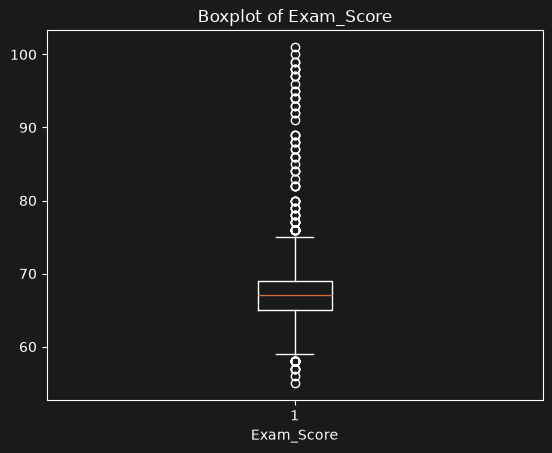

59.0
75.0
104
52
6503


In [47]:

plt.boxplot(df["Exam_Score"])
plt.title("Boxplot of Exam_Score")
plt.xlabel("Exam_Score")
plt.show()

Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Exam_Score"] < lower_bound) | (df["Exam_Score"] > upper_bound)]
print(lower_bound)
print(upper_bound)

print(len(iqr_outliers))
z_scores = np.abs(stats.zscore(df["Exam_Score"]))
z_outliers = df[z_scores > 3]
print(len(z_outliers))

df = df[(df["Exam_Score"] >= lower_bound) & (df["Exam_Score"] <= upper_bound)].reset_index(drop=True)
print(len(df))




## 3. Apply one-hot encoding to nominal variables

In [48]:

nominal_cols = ['Gender', 'School_Type', 'Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities',  'Peer_Influence']

for col in nominal_cols:
    df[col] = df[col].str.strip().str.title()

df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)


## 4. Apply ordinal encoding to ordinal variables

In [49]:
ordinal_cols = ["Parental_Involvement","Access_to_Resources","Motivation_Level","Family_Income","Teacher_Quality","Parental_Education_Level","Distance_from_Home",]

ordinal_categories = [
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["High School", "College", "Postgraduate"],
    ["Near", "Moderate", "Far"],
]

encoder = OrdinalEncoder(categories=ordinal_categories)
df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])



## 5. Split the data 80% / 20%

In [50]:

target_col = "Exam_Score"
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numerical_cols = ["Hours_Studied","Attendance","Sleep_Hours","Previous_Scores","Tutoring_Sessions","Physical_Activity"]

numerical_cols = [c for c in numerical_cols if c in X_train.columns]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5202, 26)
(1301, 26)
(5202,)
(1301,)


## 6. Exporting processed data

In [52]:
path = "../data/processed/edu-predict-clean.csv"
df.to_csv(path)